# 🛡️ End-to-End Fraud Detection Portfolio Project
**Objective:** Perform comprehensive Exploratory Data Analysis (EDA) on transaction data to uncover risk patterns, anomalies, and feature correlations for machine learning model preparation.

## 1. Data Inspection & Structure
**Objective:** Verify dataset dimensions, check schema data types, and validate that there are no missing values or duplicate records.

In [1]:
import pandas as pd

# Dataset load karna
df = pd.read_csv("Fraud_Detection_Clean_Dataset.csv")

# 1. Dataset ke dimensions check karna
print(f"Dataset Shape -> Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 2. Data types aur non-null memory counts dekhna
print("\n--- Data Schema & Info ---")
print(df.info())

# 3. Missing values check karna
print("\n--- Missing Values Check ---")
print(df.isnull().sum())

# 4. Duplicate rows check karna
print(f"\nTotal Duplicate Rows: {df.duplicated().sum()}")

Dataset Shape -> Rows: 50000, Columns: 12

--- Data Schema & Info ---
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    50000 non-null  str    
 1   User_ID                           50000 non-null  int64  
 2   Transaction_Amount                50000 non-null  float64
 3   Transaction_Type                  50000 non-null  str    
 4   Time_of_Transaction               50000 non-null  float64
 5   Device_Used                       50000 non-null  str    
 6   Location                          50000 non-null  str    
 7   Previous_Fraudulent_Transactions  50000 non-null  int64  
 8   Account_Age                       50000 non-null  int64  
 9   Number_of_Transactions_Last_24H   50000 non-null  int64  
 10  Payment_Method                    50000 non-null  str    
 11  Fraudule

## 2. Univariate Analysis & Outlier Detection
**Objective:** Analyze individual numerical distributions and detect extreme upper-bound outliers in transaction amounts.

--- Transaction Amount Summary Statistics ---
count    50000.000000
mean      2973.738990
std       4927.634162
min          5.030000
25%       1333.002500
50%       2523.430000
75%       3721.015000
max      49997.800000
Name: Transaction_Amount, dtype: float64

--- Target Class Distribution (%) ---
Fraudulent
0    95.08
1     4.92
Name: proportion, dtype: float64


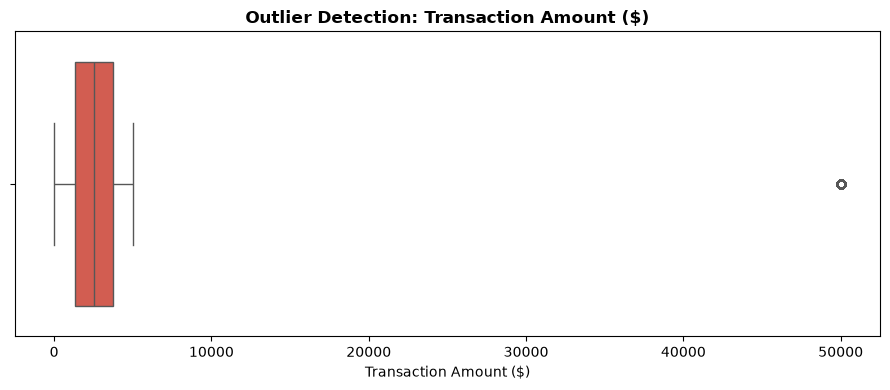

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Statistical summary for numerical features
print("--- Transaction Amount Summary Statistics ---")
print(df['Transaction_Amount'].describe())

# 2. Target class distribution (`Fraudulent`)
print("\n--- Target Class Distribution (%) ---")
print(df['Fraudulent'].value_counts(normalize=True) * 100)

# 3. Outlier Boxplot Visualization for Transaction Amount
plt.figure(figsize=(9, 4))
sns.boxplot(x=df['Transaction_Amount'], color='#e74c3c')
plt.title('Outlier Detection: Transaction Amount ($)', fontsize=12, fontweight='bold')
plt.xlabel('Transaction Amount ($)')
plt.tight_layout()
plt.show()

## 3. Bivariate & Categorical Risk Analysis
**Objective:** Evaluate how categorical features like Payment Methods, Device types, and Geographic Locations correlate with fraud rates.

--- Fraud Rate by Payment Method ---
  Payment_Method  count  fraud_rate_pct
0    Credit Card  11403        4.919758
1     Debit Card  11594        4.916336
2    Net Banking  11437        4.887645
3            UPI  11648        5.108173
4        Unknown   3918        4.466565


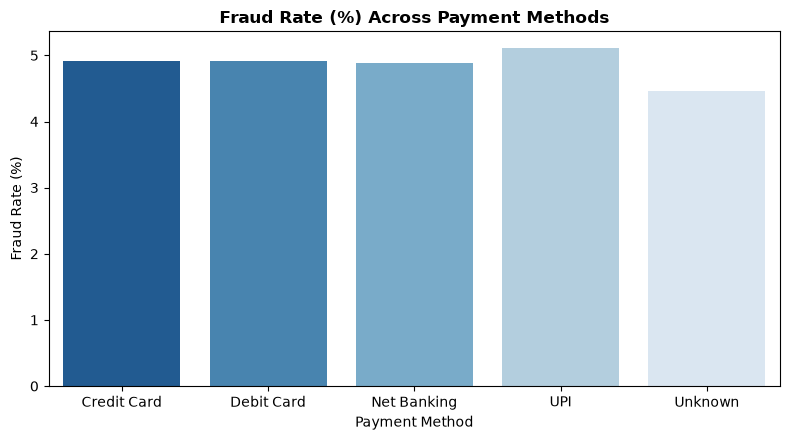

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate fraud rates by Payment Method first
pay_fraud = df.groupby('Payment_Method')['Fraudulent'].agg(['count', 'mean']).reset_index()
pay_fraud['fraud_rate_pct'] = pay_fraud['mean'] * 100

print("--- Fraud Rate by Payment Method ---")
print(pay_fraud[['Payment_Method', 'count', 'fraud_rate_pct']])

# 2. Plot with warning-free syntax
plt.figure(figsize=(8, 4.5))
sns.barplot(
    data=pay_fraud, 
    x='Payment_Method', 
    y='fraud_rate_pct', 
    hue='Payment_Method', 
    palette='Blues_r', 
    legend=False
)
plt.title('Fraud Rate (%) Across Payment Methods', fontsize=12, fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()

## 4. Temporal & Velocity Pattern Analysis
**Objective:** Uncover time-of-day operational spikes and the impact of short-term transaction frequency (velocity) on fraud likelihood.

--- Hourly Fraud Trend Summary ---
   Time_of_Transaction  fraud_rate_pct
0                  0.0        4.579393
1                  1.0        4.766683
2                  2.0        5.086470
3                  3.0        4.709965
4                  4.0        4.833837


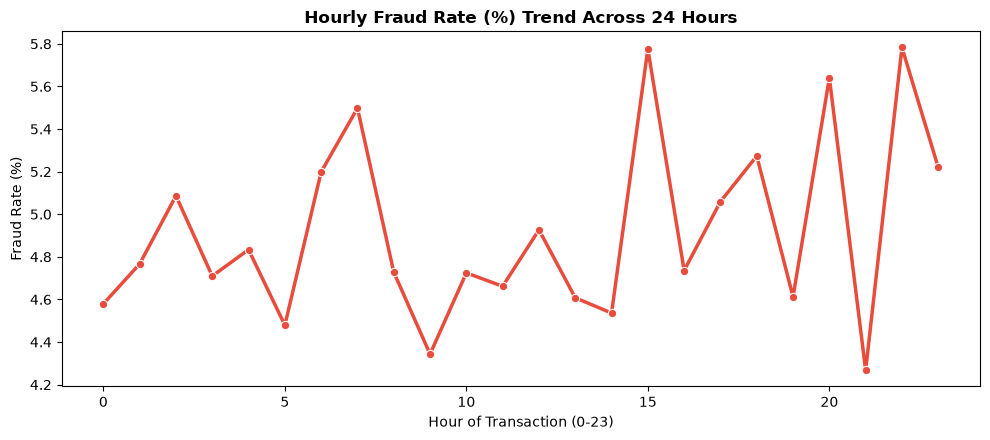

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Hourly Fraud Rate Calculation
hourly_fraud = df.groupby('Time_of_Transaction')['Fraudulent'].agg(['count', 'mean']).reset_index()
hourly_fraud['fraud_rate_pct'] = hourly_fraud['mean'] * 100
print("--- Hourly Fraud Trend Summary ---")
print(hourly_fraud[['Time_of_Transaction', 'fraud_rate_pct']].head())

# 2. Velocity Fraud Rate Calculation
vel_df = df.groupby('Number_of_Transactions_Last_24H')['Fraudulent'].agg(['count', 'mean']).reset_index()
vel_df['fraud_rate_pct'] = vel_df['mean'] * 100

# 3. Line Plot Visualization for Hourly Trend (Warning-free)
plt.figure(figsize=(10, 4.5))
sns.lineplot(
    data=hourly_fraud, 
    x='Time_of_Transaction', 
    y='fraud_rate_pct', 
    marker='o', 
    color='#e74c3c', 
    linewidth=2.5
)
plt.title('Hourly Fraud Rate (%) Trend Across 24 Hours', fontsize=12, fontweight='bold')
plt.xlabel('Hour of Transaction (0-23)')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()

## 5. Feature Correlation & Multicollinearity Matrix
**Objective:** Assess linear independence among predictor variables to prevent multicollinearity issues before model training.

--- Correlation Matrix Summary ---
                                  Fraudulent
Fraudulent                          1.000000
Time_of_Transaction                 0.005892
Account_Age                         0.005704
Transaction_Amount                  0.004854
Previous_Fraudulent_Transactions    0.000634
Number_of_Transactions_Last_24H    -0.003891


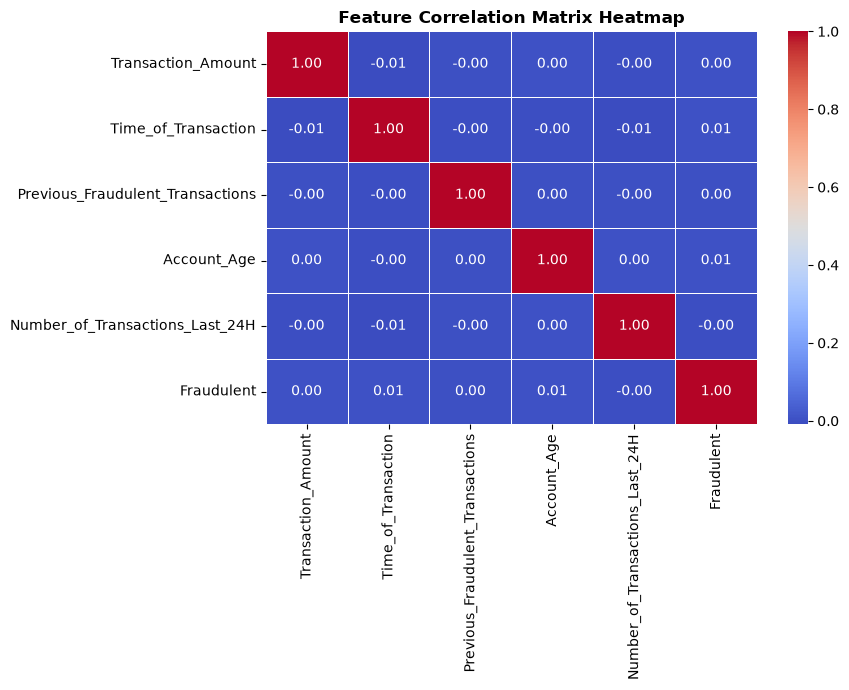

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select numerical features for correlation matrix
num_cols = ['Transaction_Amount', 'Time_of_Transaction', 'Previous_Fraudulent_Transactions', 
            'Account_Age', 'Number_of_Transactions_Last_24H', 'Fraudulent']

# Compute correlation matrix
corr_matrix = df[num_cols].corr()
print("--- Correlation Matrix Summary ---")
print(corr_matrix[['Fraudulent']].sort_values(by='Fraudulent', ascending=False))

# 2. Heatmap Visualization
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5, 
    cbar=True,
    annot_kws={"size": 10}
)
plt.title('Feature Correlation Matrix Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6: Business Impact & Strategic Recommendations

**Objective:** 
To translate technical EDA findings and financial exposure metrics into actionable business strategies for Risk Operations, Product, and Management teams to mitigate fraud.

In [6]:
# Calculating potential financial exposure
total_transactions = len(df)
fraud_count = df['Fraudulent'].sum()
fraud_amount_exposure = df[df['Fraudulent'] == 1]['Transaction_Amount'].sum()

print(f"Total Fraudulent Transactions: {fraud_count} ({df['Fraudulent'].mean()*100:.2f}%)")
print(f"Total Financial Exposure from Fraud: ${fraud_amount_exposure:,.2f}")

Total Fraudulent Transactions: 2460 (4.92%)
Total Financial Exposure from Fraud: $7,574,078.91


## Conclusion

**Objective:** 
Acknowledge analytical constraints, establish a production operationalization blueprint, and outline key performance indicators (KPIs) for the risk management pipeline.

### 1. Analytical Limitations & Blind Spots
* **Retrospective Bias:** This EDA is based on static historical batch data; real-time fraud vectors evolve rapidly via zero-day attacks.
* **Omitted Behavioral Metadata:** Device fingerprinting, IP geolocation proxies, and behavioral biometrics (such as typing cadence or touch velocity) were not present in this dataset.
* **Friction vs. Security Trade-off:** Over-aggressive rule implementation risks driving up False Positives (FPR), directly frustrating and churning legitimate users.

### 2. Operationalization Blueprint (From Insights to Production)
* **Real-Time Feature Store:** Push rolling velocity metrics (`Number_of_Transactions_Last_24H`) and historical aggregates into a low-latency feature store (e.g., Redis) for sub-100ms API inference.
* **Analyst Feedback Loop:** Establish a dedicated review queue where Fraud Operations analysts can disposition flagged transactions, feeding labels back into the system to refine risk rules.
* **Staged Rollout (A/B Testing):** Deploy new risk rules to a 10% canary traffic pool first to monitor False Positive Rates before scaling to 100% production traffic.

### 3. Production Success Metrics (KPIs)
* **Fraud Capture Rate (Recall):** Target intercepting $>85\%$ of fraudulent value without choking transaction flow.
* **False Positive Rate (FPR):** Maintain $<1\%$ to protect legitimate checkout conversion rates.
* **Analyst Efficiency:** Reduce manual case-review backlogs by automating low-risk velocity filters.